<a href="https://colab.research.google.com/github/JohnUfo/python-and-scikit-tutorial/blob/main/rain_prediction_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import os
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [51]:
raw_df = pd.read_csv('/content/drive/MyDrive/weather-dataset-rattle-package/weatherAUS.csv')

# EDA (Exploratory Data Analysis)

In [18]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [19]:
raw_df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


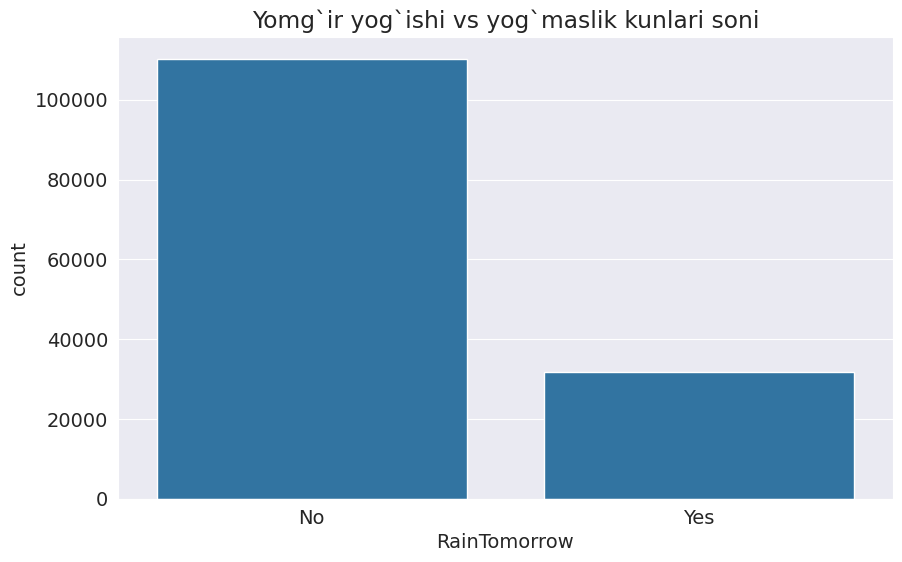

In [20]:
sns.countplot(data=raw_df, x='RainTomorrow')
plt.title('Yomg`ir yog`ishi vs yog`maslik kunlari soni')
plt.show()

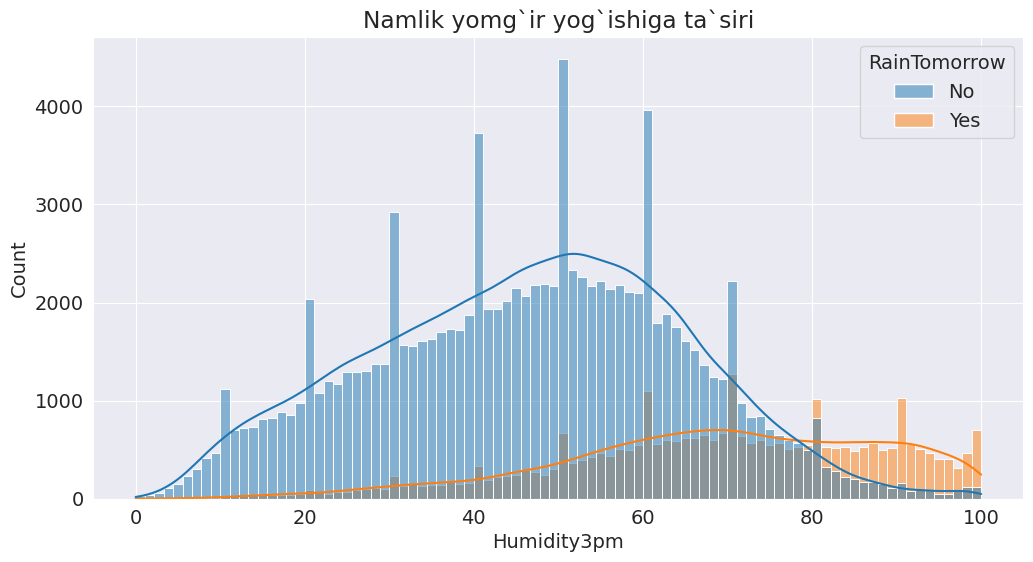

In [21]:
plt.figure(figsize=(12,6))
sns.histplot(data=raw_df, x='Humidity3pm', hue='RainTomorrow', kde=True)
plt.title('Namlik yomg`ir yog`ishiga ta`siri')
plt.show()

# Correlation Heatmap

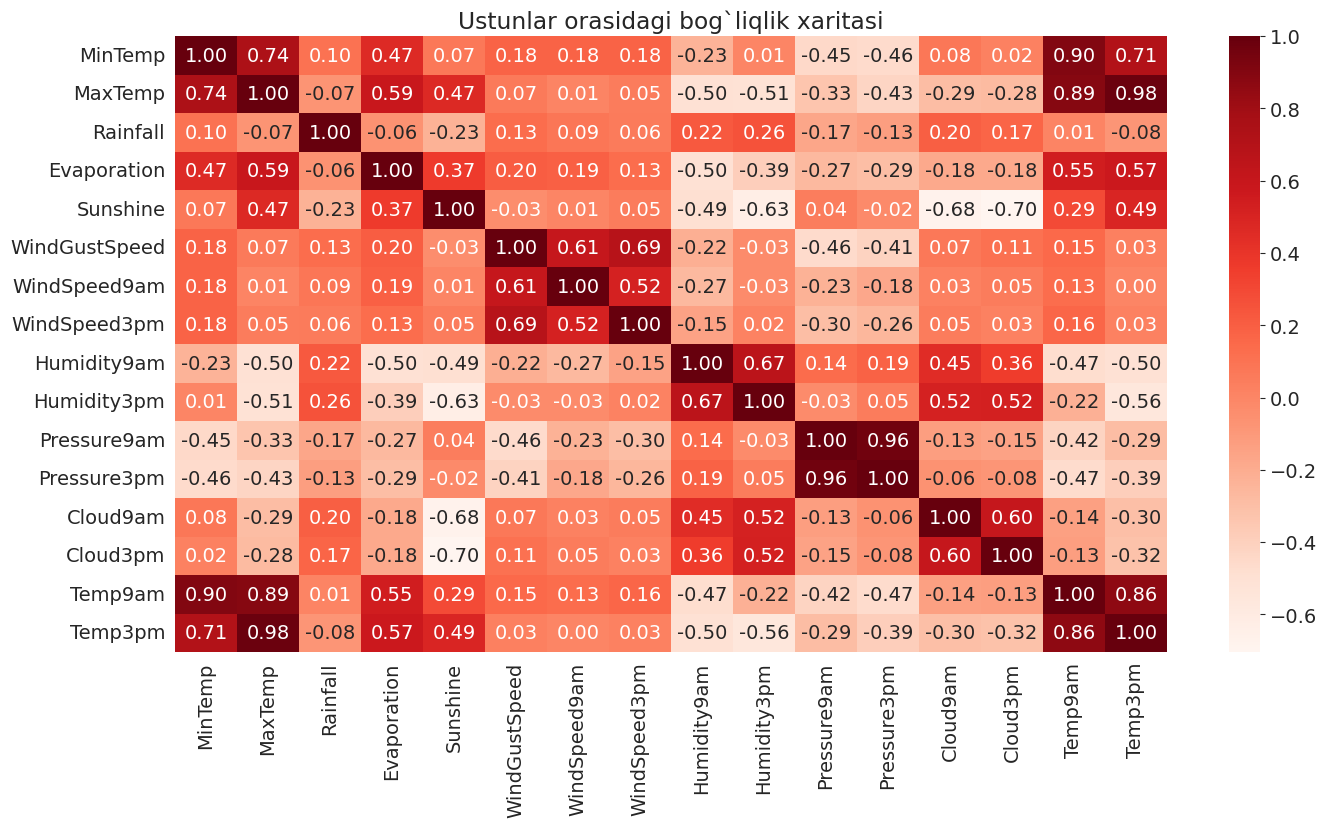

In [22]:
plt.figure(figsize=(16, 8))
# Faqat sonli ustunlarni olamiz
numeric_df = raw_df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='Reds', fmt='.2f')
plt.title('Ustunlar orasidagi bog`liqlik xaritasi')
plt.show()

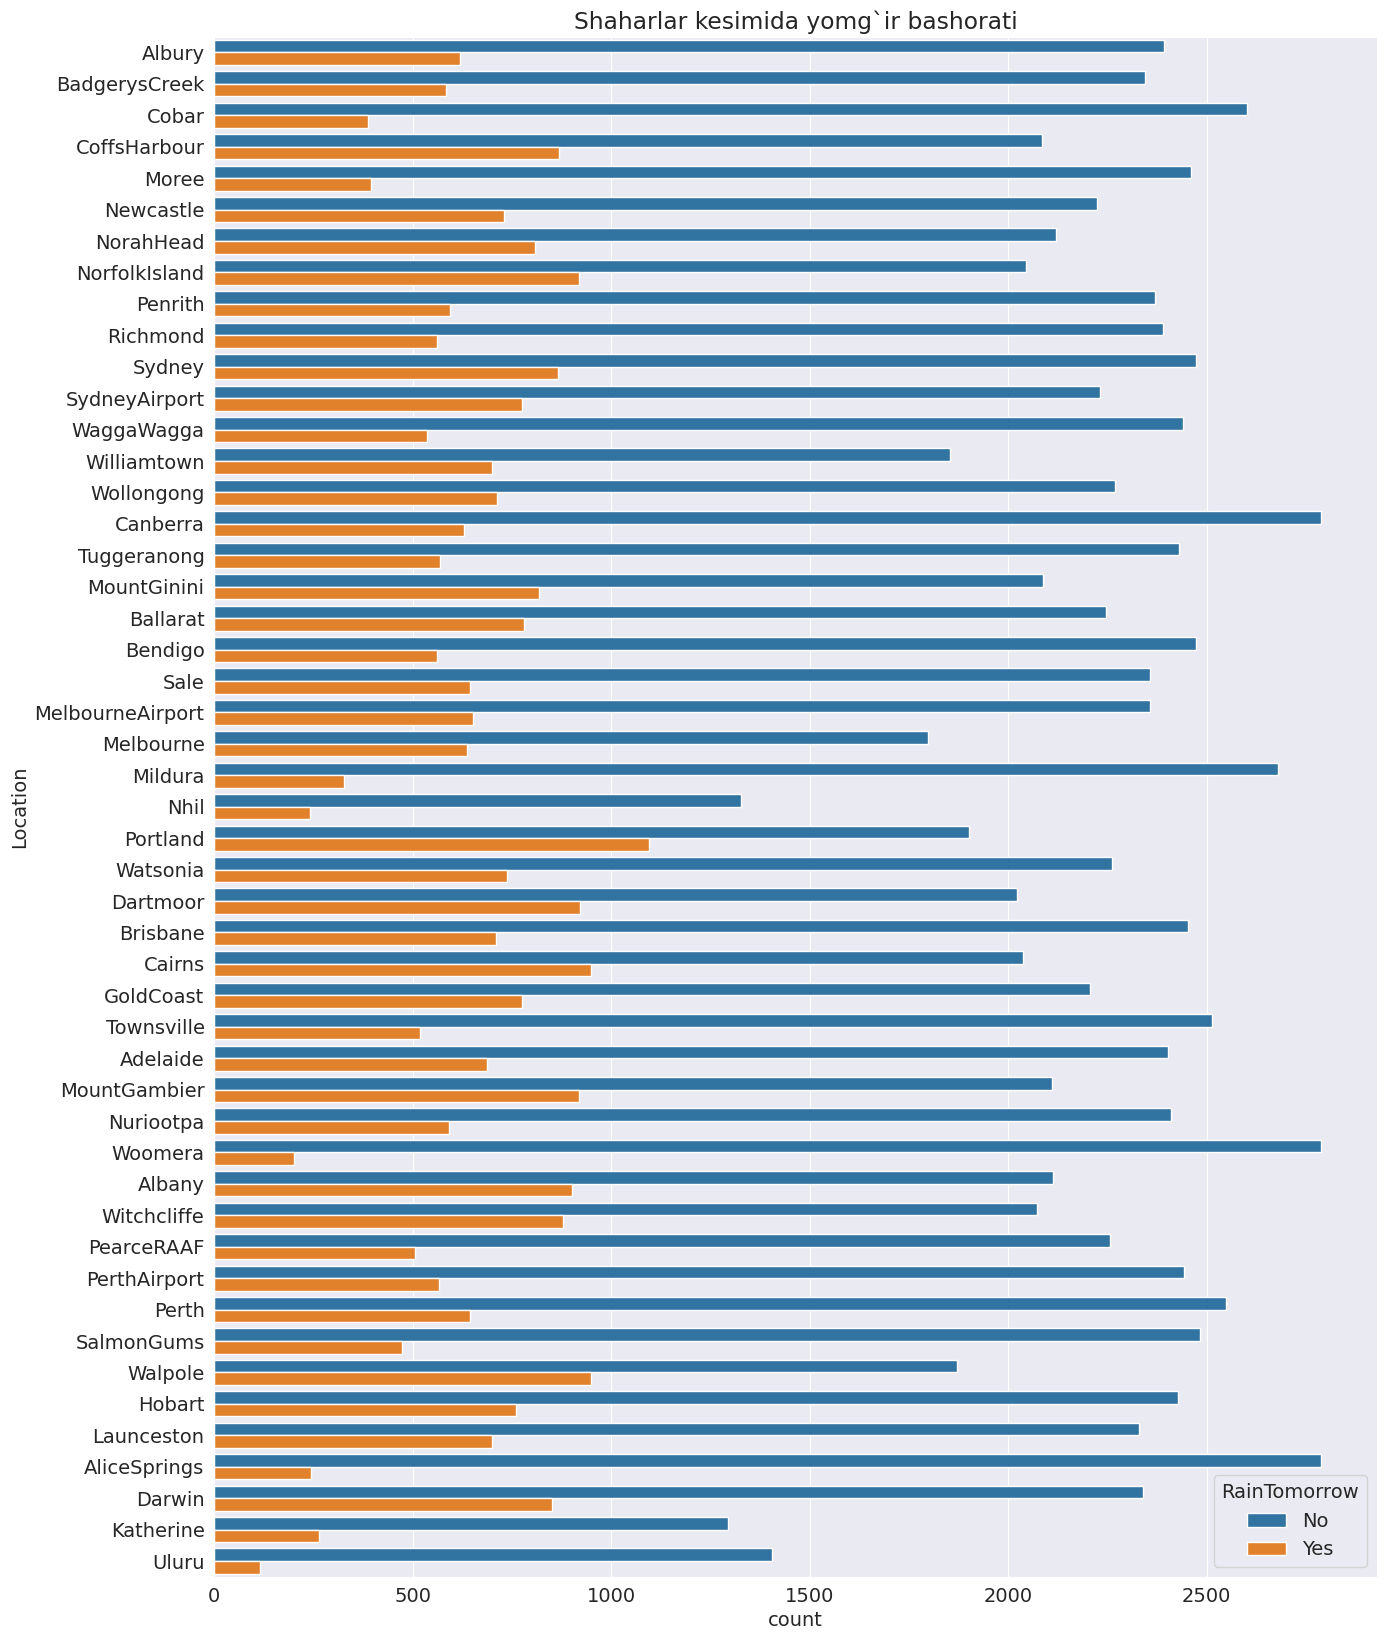

In [23]:
plt.figure(figsize=(15, 20))
sns.countplot(data=raw_df, y='Location', hue='RainTomorrow')
plt.title('Shaharlar kesimida yomg`ir bashorati')
plt.show()

In [24]:
import plotly.express as px

px.histogram(raw_df, x='Temp3pm', color='RainTomorrow', title='Temperature at 3pm vs Rain Tomorrow')

# Data Preparation

In [25]:
raw_df.dropna(subset=['RainTomorrow'], inplace=True)

In [26]:
raw_df['Date'] = pd.to_datetime(raw_df['Date'])
train_df = raw_df[raw_df['Date'].dt.year < 2015].copy()
val_df = raw_df[raw_df['Date'].dt.year == 2015].copy()
test_df = raw_df[raw_df['Date'].dt.year > 2015].copy()

print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")
print(f"Test: {len(test_df)}")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")

Train: 98988
Validation: 17231
Test: 25974
Total: 142193


In [27]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

imputer.fit(train_df[numeric_cols])

train_df[numeric_cols] = imputer.transform(train_df[numeric_cols])
val_df[numeric_cols] = imputer.transform(val_df[numeric_cols])
test_df[numeric_cols] = imputer.transform(test_df[numeric_cols])

In [28]:
train_df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,5.28686,7.602136,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.414451,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,5.28686,7.602136,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,4.308048,4.414451,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,5.28686,7.602136,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,4.308048,2.000000,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,5.28686,7.602136,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,4.308048,4.414451,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,5.28686,7.602136,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,No,No


# Pre-Processing

*Sonlarni kichraytirish (Scaling)*

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_df[numeric_cols])

train_df[numeric_cols] = scaler.transform(train_df[numeric_cols])
val_df[numeric_cols] = scaler.transform(val_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])

*Matnlarni sonlarga o'girish (One-Hot Encoding)*

In [30]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('RainTomorrow')
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(train_df[categorical_cols].fillna('Unknown'))
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

train_encoded = encoder.transform(train_df[categorical_cols].fillna('Unknown'))
val_encoded = encoder.transform(val_df[categorical_cols].fillna('Unknown'))
test_encoded = encoder.transform(test_df[categorical_cols].fillna('Unknown'))

train_df = pd.concat([train_df, pd.DataFrame(train_encoded, columns=encoded_cols, index=train_df.index)], axis=1)
val_df = pd.concat([val_df, pd.DataFrame(val_encoded, columns=encoded_cols, index=val_df.index)], axis=1)
test_df = pd.concat([test_df, pd.DataFrame(test_encoded, columns=encoded_cols, index=test_df.index)], axis=1)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

In [31]:
input_cols = numeric_cols + encoded_cols
X_train = train_df[input_cols]
y_train = train_df['RainTomorrow']

X_val = val_df[input_cols]
y_val = val_df['RainTomorrow']

X_test = test_df[input_cols]
y_test = test_df['RainTomorrow']

In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(solver='liblinear', class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', solver='liblinear')

In [33]:
from sklearn.metrics import accuracy_score

train_preds = model.predict(X_train)
print(f"Training Accuracy: {accuracy_score(y_train, train_preds)}")

val_preds = model.predict(X_val)
print(f"Validation Accuracy: {accuracy_score(y_val, val_preds)}")

Training Accuracy: 0.7979654099486806
Validation Accuracy: 0.8129533979455632


# Confusion Matrix

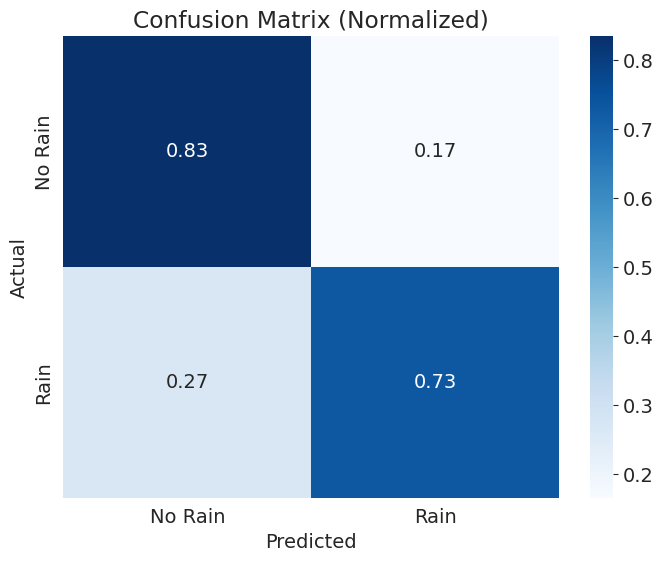

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, val_preds, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Normalized)')
plt.show()

# The Final Exam

Test Accuracy: 0.7931392931392931


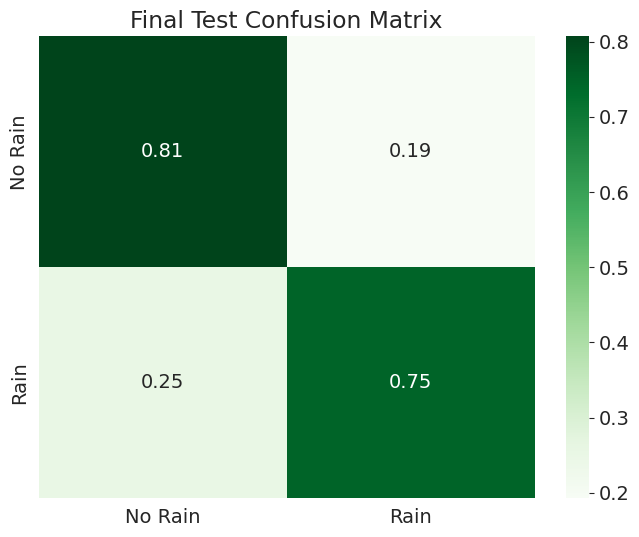

In [35]:
test_preds = model.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, test_preds)}")

cm_test = confusion_matrix(y_test, test_preds, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, cmap='Greens', xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
plt.title('Final Test Confusion Matrix')
plt.show()

# DecisionTreeClassifier

In [36]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [37]:
train_preds = model.predict(X_train)

In [38]:
accuracy_score(train_preds, y_train)

0.9999797955307714

In [39]:
train_probs = model.predict_proba(X_train)
train_probs

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [40]:
model.score(X_val,y_val)

0.7929893796065232

In [41]:
y_val.value_counts() / len(y_val)

,count
RainTomorrow,
No,0.788289
Yes,0.211711


In [42]:
from sklearn.tree import plot_tree, export_text

[Text(0.5, 0.875, 'Humidity3pm <= 0.715\ngini = 0.349\nsamples = 98988\nvalue = [76705, 22283]'),
 Text(0.25, 0.625, 'Rainfall <= 0.004\ngini = 0.248\nsamples = 82418\nvalue = [70439.0, 11979.0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'Sunshine <= 0.532\ngini = 0.198\nsamples = 69252\nvalue = [61538.0, 7714.0]'),
 Text(0.0625, 0.125, '\n  (...)  \n'),
 Text(0.1875, 0.125, '\n  (...)  \n'),
 Text(0.375, 0.375, 'Humidity3pm <= 0.513\ngini = 0.438\nsamples = 13166\nvalue = [8901, 4265]'),
 Text(0.3125, 0.125, '\n  (...)  \n'),
 Text(0.4375, 0.125, '\n  (...)  \n'),
 Text(0.75, 0.625, 'Humidity3pm <= 0.825\ngini = 0.47\nsamples = 16570\nvalue = [6266, 10304]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'WindGustSpeed <= 0.279\ngini = 0.499\nsamples = 9136\nvalue = [4804, 4332]'),
 Text(0.5625, 0.125, '\n  (...)  \n'),
 Text(0.6875, 0.125, '\n  (...)  \n'),
 Text(0.875, 0.375, 'Rainfall <= 0.01\ngini = 0.316\nsamples = 7434\nvalue = [1462, 5972]'),
 Text(0.8125, 0.125,

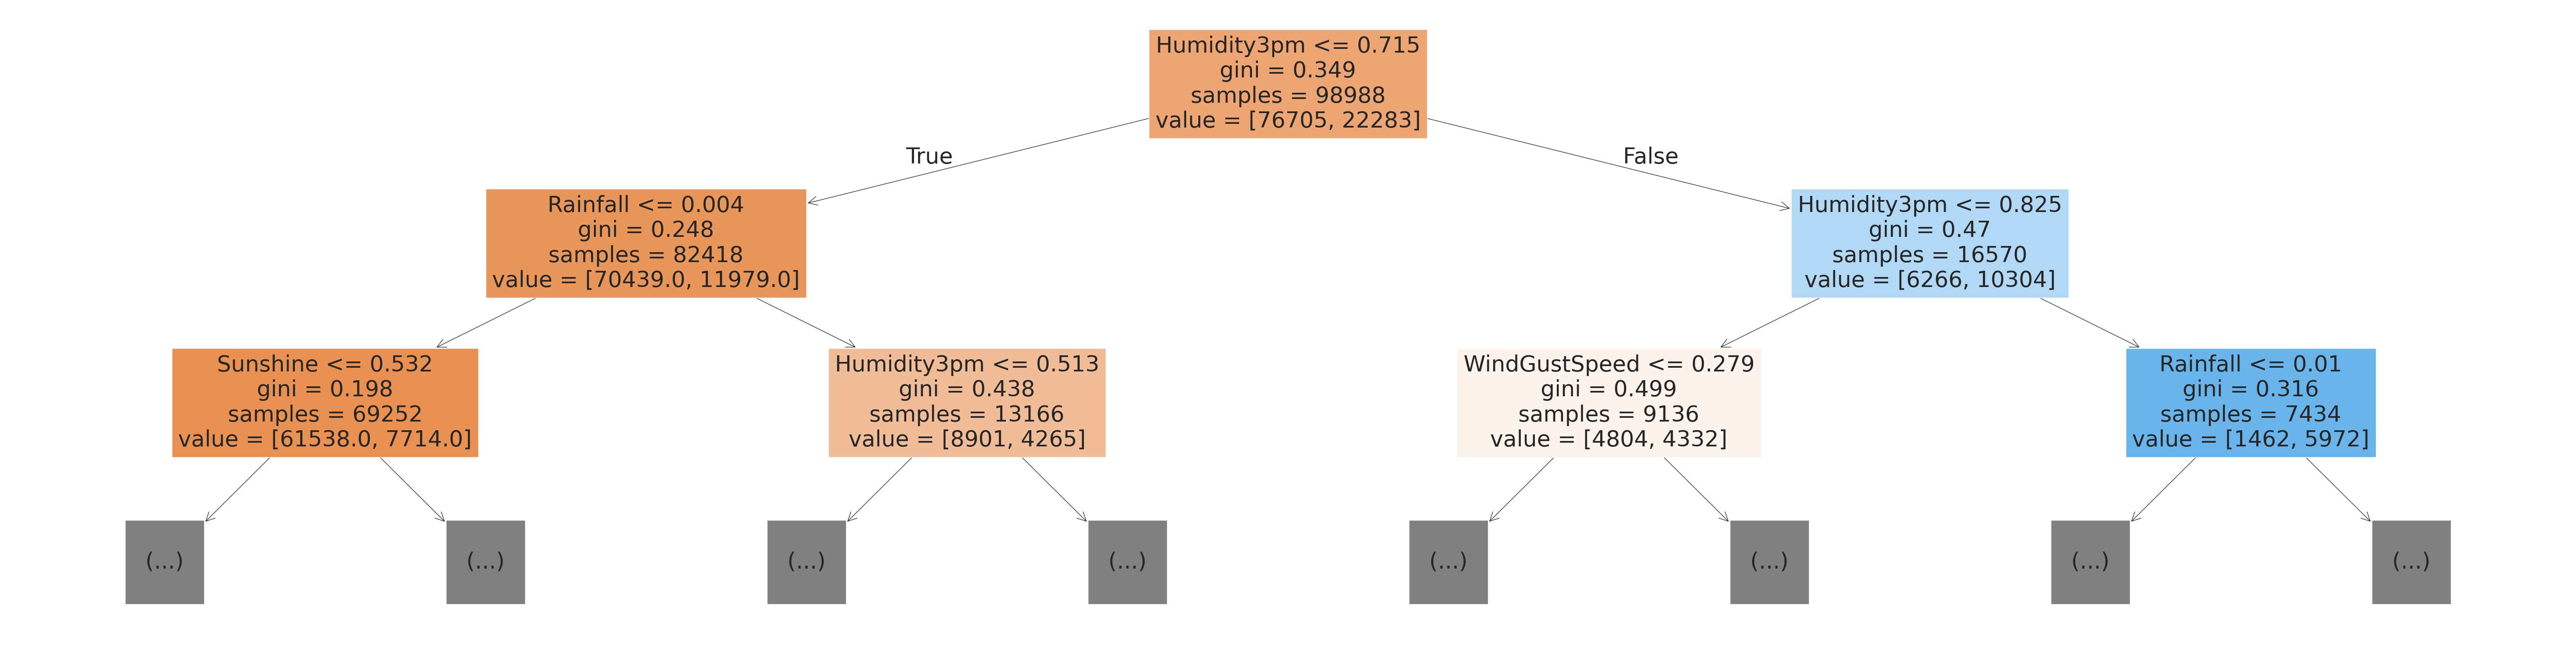

In [43]:
plt.figure(figsize=(80, 20))
plot_tree(model, feature_names=X_train.columns, max_depth=2 ,filled=True)

In [44]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [45]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [46]:
model.score(X_train, y_train)

0.8291308037337859

In [47]:
model.score(X_val, y_val)

0.8334397307178921

In [48]:
def max_depth_error(md):
  model = DecisionTreeClassifier(max_depth=md, random_state=42)
  model.fit(X_train, y_train)
  train_error = 1 - model.score(X_train, y_train)
  val_error = 1 - model.score(X_val, y_val)
  return {'Max Depth' : md, 'Training Error' : train_error, 'Validation Error' : val_error}

In [49]:
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 20)])

In [52]:
errors_df

,Max Depth,Training Error,Validation Error
0,1,0.184315,0.177935
1,2,0.179547,0.172712
2,3,0.170869,0.166560
3,4,0.165707,0.164355
4,5,0.160676,0.159074
5,6,0.156271,0.157275
6,7,0.153312,0.154605
7,8,0.147806,0.157971
8,9,0.140967,0.156636
9,10,0.132996,0.157217


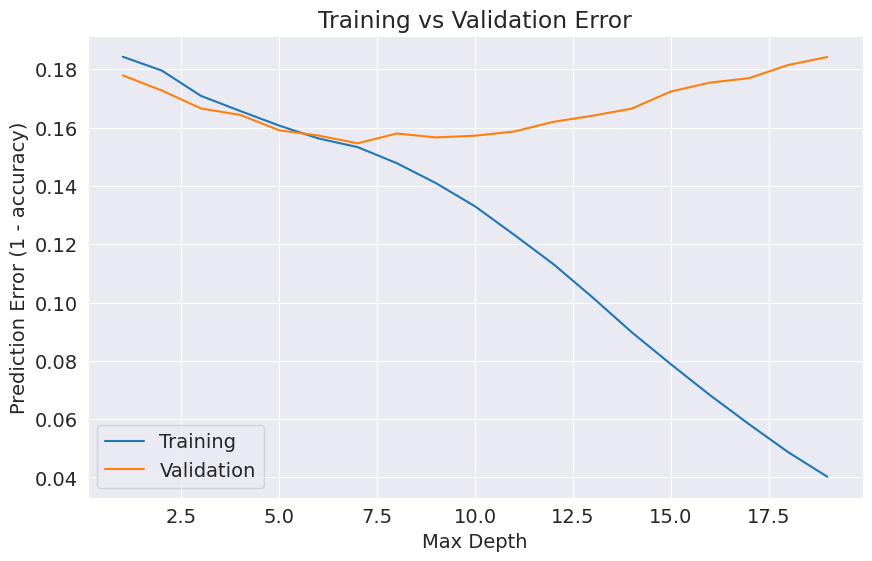

In [55]:
plt.figure()
plt.plot(errors_df['Max Depth'], errors_df['Training Error'])
plt.plot(errors_df['Max Depth'], errors_df['Validation Error'])
plt.title('Training vs Validation Error')
plt.xlabel('Max Depth')
plt.ylabel('Prediction Error (1 - accuracy)')
plt.legend(['Training', 'Validation'])
plt.show()

In [58]:
model = DecisionTreeClassifier(max_depth=7, random_state=42).fit(X_train,y_train)
model.score(X_train,y_train) ,model.score(X_val,y_val)

(0.8466884874934335, 0.8453949277465034)

In [67]:
model = DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [68]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=128, random_state=42)

In [69]:
model.score(X_train, y_train)


0.8480421869317493

In [70]:
model.tree_.max_depth

12

# Hyperparameter Tuning

In [79]:
depths = [3, 5, 7, 10, 15]
leaf_nodes = [10, 50, 100, 200, 500]

best_score = 0
best_params = {}

for d in depths:
  for l in leaf_nodes:
    model = DecisionTreeClassifier(max_depth=d, max_leaf_nodes=l, random_state=42)
    model.fit(X_train, y_train)
    score = model.score(X_val, y_val)
    print(f"Depth: {d}, Leafs: {l}, Score: {score:.4f}")
    if score > best_score:
      best_score = score
      best_params['max_depth'] = d
      best_params['max_leaf_nodes'] = l

print(f"Best Score: {best_score:.4f}")
print(f"Best Params: {best_params}")

Depth: 3, Leafs: 10, Score: 0.8334
Depth: 3, Leafs: 50, Score: 0.8334
Depth: 3, Leafs: 100, Score: 0.8334
Depth: 3, Leafs: 200, Score: 0.8334
Depth: 3, Leafs: 500, Score: 0.8334
Depth: 5, Leafs: 10, Score: 0.8352
Depth: 5, Leafs: 50, Score: 0.8409
Depth: 5, Leafs: 100, Score: 0.8409
Depth: 5, Leafs: 200, Score: 0.8409
Depth: 5, Leafs: 500, Score: 0.8409
Depth: 7, Leafs: 10, Score: 0.8352
Depth: 7, Leafs: 50, Score: 0.8430
Depth: 7, Leafs: 100, Score: 0.8450
Depth: 7, Leafs: 200, Score: 0.8454
Depth: 7, Leafs: 500, Score: 0.8454
Depth: 10, Leafs: 10, Score: 0.8352
Depth: 10, Leafs: 50, Score: 0.8430
Depth: 10, Leafs: 100, Score: 0.8439
Depth: 10, Leafs: 200, Score: 0.8450
Depth: 10, Leafs: 500, Score: 0.8440
Depth: 15, Leafs: 10, Score: 0.8352
Depth: 15, Leafs: 50, Score: 0.8430
Depth: 15, Leafs: 100, Score: 0.8443
Depth: 15, Leafs: 200, Score: 0.8444
Depth: 15, Leafs: 500, Score: 0.8437
Best Score: 0.8454
Best Params: {'max_depth': 7, 'max_leaf_nodes': 200}


# COST-COMPLEXITY-PRUNING(CCP)

In [81]:
path = model.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

In [ ]:
models = []
for alpha in ccp_alphas:
  m = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
  m.fit(X_train, y_train)
  models.append(m)

train_scores = [m.score(X_train, y_train) for m in models]
val_scores = [m.score(X_val, y_val) for m in models]